In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv(r"arsenals_player_clean.csv")
df

,jersey_number,name,position,nationality,dob,height_cm,foot,joined,contract,market_value_millons,age
0,1,David Raya,Goalkeeper,Spain,1995-09-15,183,right,2024-07-04,2028-06-30,35.0,30
1,13,Kepa Arrizabalaga,Goalkeeper,Spain,1994-10-03,188,right,2025-07-01,2028-06-30,7.0,31
2,35,Tommy Setford,Goalkeeper,England,2006-03-13,185,right,2025-07-01,2028-06-30,NaN,20
3,2,William Saliba,Centre-Back,France,2001-03-24,192,right,2019-07-25,2030-06-30,90.0,25
4,6,Gabriel,Centre-Back,Brazil,1997-12-19,190,left,2020-09-01,2029-06-30,75.0,28
5,5,Piero Hincapié,Centre-Back,Ecuador,2002-01-09,184,left,2025-09-01,2026-06-30,50.0,24
6,3,Cristhian Mosquera,Centre-Back,Spain,2004-06-27,191,right,2025-07-24,2030-06-30,35.0,21
7,33,Riccardo Calafiori,Left-Back,Italy,2002-05-19,188,left,2024-07-29,2029-06-30,50.0,23
8,49,Myles Lewis-Skelly,Left-Back,England,2006-09-26,178,left,2024-07-01,2030-06-30,35.0,19
9,12,Jurriën Timber,Right-Back,Netherlands,2001-06-17,179,right,2023-07-14,2028-06-30,70.0,24


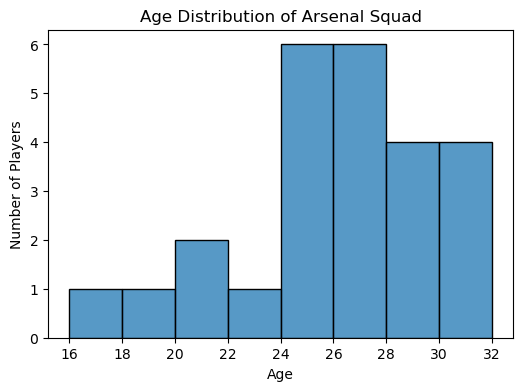

In [8]:
## SECTION 1 Squad composition
## age distribution

plt.figure(figsize=(6, 4))
sns.histplot(data=df, x='age', bins=8)
plt.title('Age Distribution of Arsenal Squad')
plt.xlabel('Age')
plt.ylabel('Number of Players')
plt.show()

Most Arsenal players are between 24-28 years old, suggesting 
the club prioritises players in their prime years rather than 
very young or aging players.

2. NATONALITY BREAKDOWN

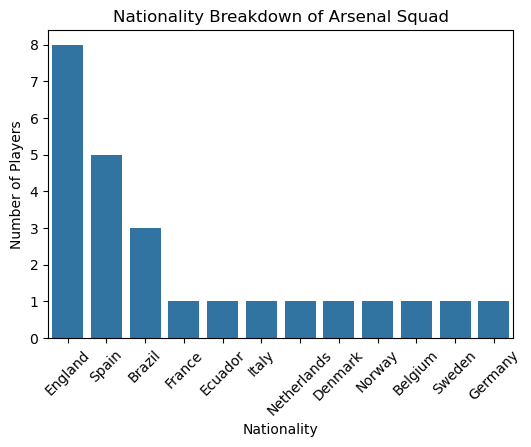

In [11]:
nationality_counts = df['nationality'].value_counts()

plt.figure(figsize=(6, 4))
sns.barplot(x=nationality_counts.index, y=nationality_counts.values)
plt.title('Nationality Breakdown of Arsenal Squad')
plt.xlabel('Nationality')
plt.ylabel('Number of Players')
plt.xticks(rotation=45)
plt.show()

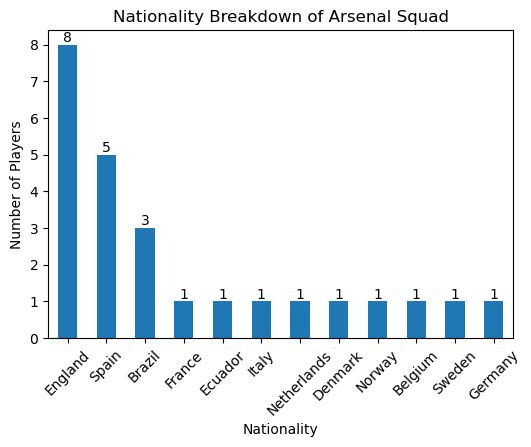

In [13]:
plt.figure(figsize=(6, 4))
ax = df['nationality'].value_counts().plot(kind='bar')
ax.bar_label(ax.containers[0])
plt.title('Nationality Breakdown of Arsenal Squad')
plt.xlabel('Nationality')
plt.ylabel('Number of Players')
plt.xticks(rotation=45)
plt.show()

Arsenal’s squad is highly international, with players from 12 different nationalities. England dominates with 8 players, followed by Spain with 5 and Brazil with 3, reflecting the club’s strong scouting network across Europe and South America. The remaining 9 nationalities each have one representative, showing Arsenal prioritises quality over regional bias in their recruitment.

3. LEFT FOOT VS RIGHT FOOT RATIO

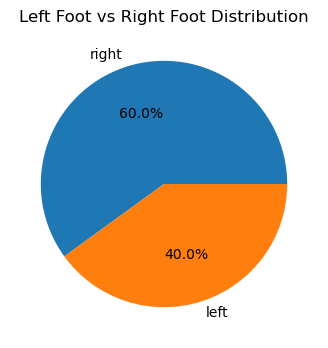

In [15]:
## to get percentage use autopct='%1.1f%%'
plt.figure(figsize=(4, 4))
df['foot'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Left Foot vs Right Foot Distribution')
plt.ylabel('')
plt.show()

60% of Arsenal players are right-footed and 40% are left-footed. This is a surprisingly balanced squad in most football teams left-footed players are 
significantly rarer, making Arsenal’s proportion of left-footed players unusually high.

In [ ]:
## SECTION 2
## MARKET VALUE ANALYSIS

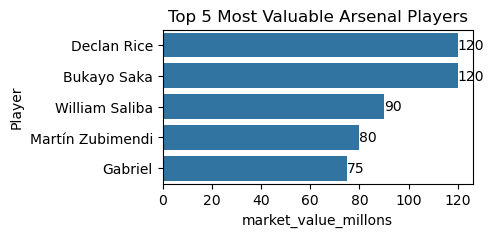

In [31]:
## this op5 = df.nlargest(5, 'market_value_millons') sot data frame by market value and return the top 5 rows
top5 = df.nlargest(5, 'market_value_millons')

plt.figure(figsize=(4, 2))
sns.barplot(x='market_value_millons', y='name', data=top5)
plt.title('Top 5 Most Valuable Arsenal Players')
plt.xlabel('market_value_millons')
plt.ylabel('Player')
ax = plt.gca()
ax.bar_label(ax.containers[0])
plt.show()

Declan Rice and Bukayo Saka are joint highest valued at €120m each, making them Arsenal’s most prized assets. William Saliba follows at €90m, 
reflecting the premium placed on elite defenders. The top 5 are all valued above €75m, suggesting Arsenal have built a squad of consistently high-value
players with no over-reliance on a single star.

## 5. Average market value by position


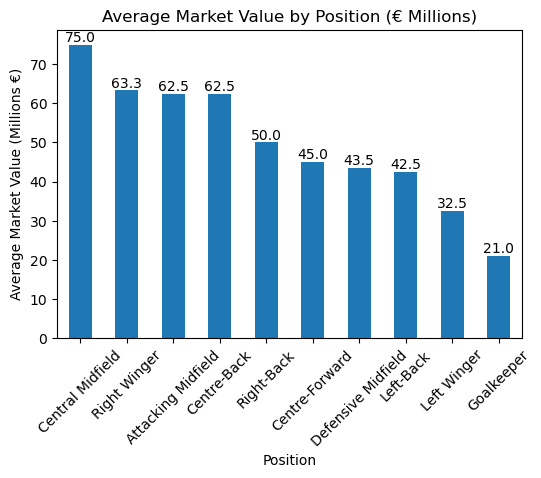

In [22]:
avg_value = df.groupby('position')['market_value_millons'].mean().sort_values(ascending=False)

plt.figure(figsize=(6, 4))
ax = avg_value.plot(kind='bar')
ax.bar_label(ax.containers[0], fmt='%.1f')
plt.title('Average Market Value by Position (€ Millions)')
plt.xlabel('Position')
plt.ylabel('Average Market Value (Millions €)')
plt.xticks(rotation=45)
plt.show()

Central Midfielders are Arsenal’s highest valued position at €75m average, followed closely by wingers and attacking midfielders. Goalkeepers have the
lowest average value at €21m, reflecting the general market trend of outfield players commanding premium prices.

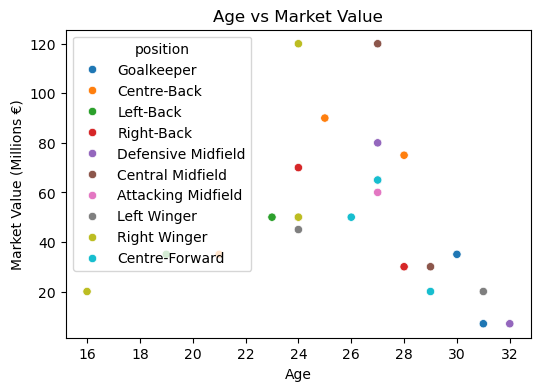

In [23]:
## 6. Age VS market value
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x='age', y='market_value_millons', hue='position')
plt.title('Age vs Market Value')
plt.xlabel('Age')
plt.ylabel('Market Value (Millions €)')
plt.show()

Players aged 24-28 tend to command the highest market values, confirming that prime-age players are valued most in football. As players approach 30 and
beyond, market values drop significantly regardless of position. The two highest valued players — both at €120m — fall within the 24-26 age bracket, 
reinforcing this trend.

## 6. Contract expiry risk

In [25]:
df['contract'] = pd.to_datetime(df['contract'], errors='coerce')
df['contract_year'] = df['contract'].dt.year

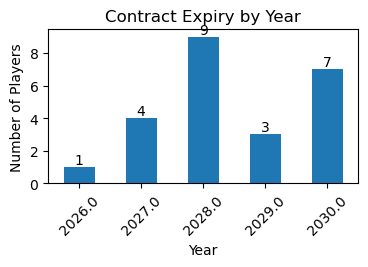

In [30]:
df['contract_year'] = df['contract'].dt.year

plt.figure(figsize=(4, 2))
ax = df['contract_year'].value_counts().sort_index().plot(kind='bar')
ax.bar_label(ax.containers[0])
plt.title('Contract Expiry by Year')
plt.xlabel('Year')
plt.ylabel('Number of Players')
plt.xticks(rotation=45)
plt.show()

2028 has the highest number of contract expirations with 9 players, followed by 2030 with 7. Only 1 player’s contract expires in 2026, meaning Arsenal 
face minimal immediate squad rebuild pressure. However the 2028 expiry cluster represents a significant contract renewal challenge the club will need 
to manage proactively.